# Compare mosaics

To fill the internal gap in the F200 and F090 images that is saturated we used the IFU data to construct equialent F200 images for the central region. 

But when coadding the IFU data to the F200W image I used the reproject interp algorithm, which is not flux preserving and want to compare how it differs between the two.

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


In [3]:
interp_image = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits")

In [4]:
exact_image = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked_exact.fits")

In [7]:
res = {'x_cen': 7537.219884279368, 'y_cen': 7332.548985227105, 'cutout_origin': (7438, 7233), 'cutout_shape': (201, 201), 'success': True, 'fun': 634828122.6442474}
elip_par = {'pixels_used': 3201601, 'peak_yx': (7332, 7538), 'mean_yx': (7364.017702693088, 7532.88931445317), 'theta_deg': -0.7818587242987439, 'astro_pa_deg': 90.78185872429874, 'q': 0.2939043540079123, 'eps': 0.7060956459920877, 'sigma_major_pix': 737.4714742203379, 'sigma_minor_pix': 216.7460772299912, 'major_axis_pix': 2949.8858968813515, 'inclination_deg': 72.90815072586739, 'cutout_origin': (5537, 5333), 'cutout_shape': (4001, 4001), 'sky': 2.9966928958892822}

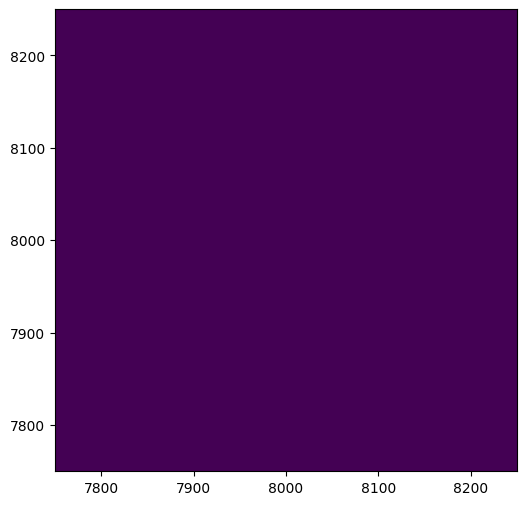

In [6]:
# make a ratio image
ratio = exact_image[0].data / interp_image[0].data

# plot the ratio image
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    ratio,
    origin="lower",
    vmin=np.nanpercentile(ratio, 5),
    vmax=np.nanpercentile(ratio, 95),
)
ax.set_xlim(7750, 8250)
ax.set_ylim(7750, 8250)
plt.show()

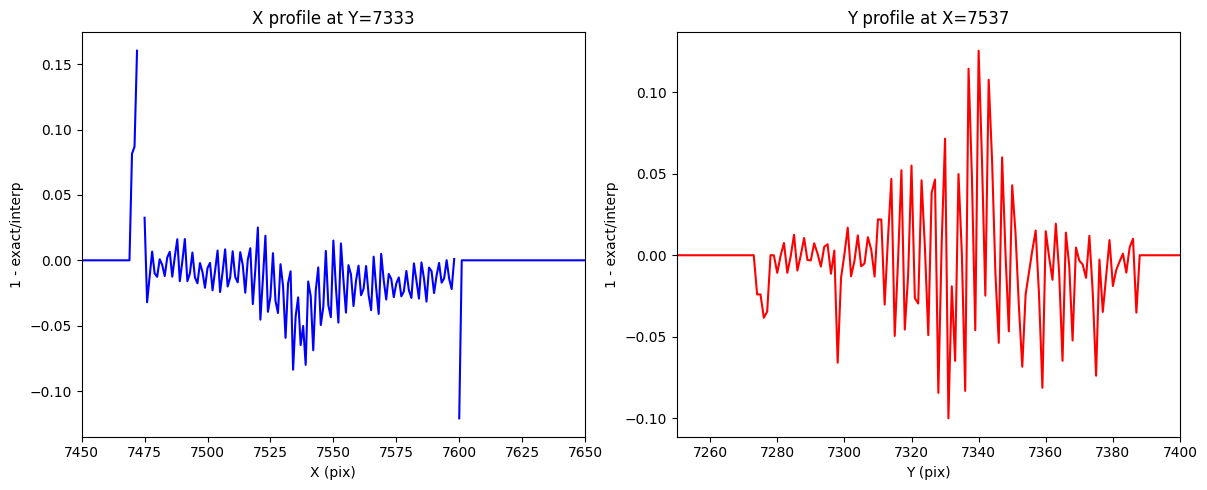

In [22]:
# plot the hisogram of the ratio image in the central region in XY
# plot count histogram in the X direction at the Y center and the Y direction at the X center
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
yc, xc = res["y_cen"], res["x_cen"]
y_center = int(round(yc))
x_center = int(round(xc))
ax[0].plot(1 - ratio[y_center, :], color='blue')
ax[0].set_title(f"X profile at Y={y_center}")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("1 - exact/interp")
ax[1].plot(1-ratio[:, x_center], color='red')
ax[1].set_title(f"Y profile at X={x_center}")
ax[1].set_xlabel("Y (pix)")
ax[1].set_ylabel("1 - exact/interp")

# add vertical lines at the center and at the edges of the zoomed region

# ax[0].axvline(x=xc, color='black', linestyle='-')

# ax[1].axvline(x=yc, color='black', linestyle='-')
plt.tight_layout()
#fig.savefig(os.path.join(checkplot_dir, f"{prefix}_02_profiles.png"), dpi=dpi)
#plt.close(fig)#
ax[0].set_xlim(7450, 7650)
ax[1].set_xlim(7250, 7400)

plt.show()

In [43]:
# compute the median absolute deviation between the two in the central region
center_region_exact = exact_image[0].data[7250:7400, 7450:7650]
center_region_interp = interp_image[0].data[7250:7400, 7450:7650]

mad = np.nanmean(np.abs(center_region_exact - center_region_interp))/np.nanmean(center_region_exact)
print(f"Median absolute deviation: {mad}")

Median absolute deviation: 0.011326970532536507


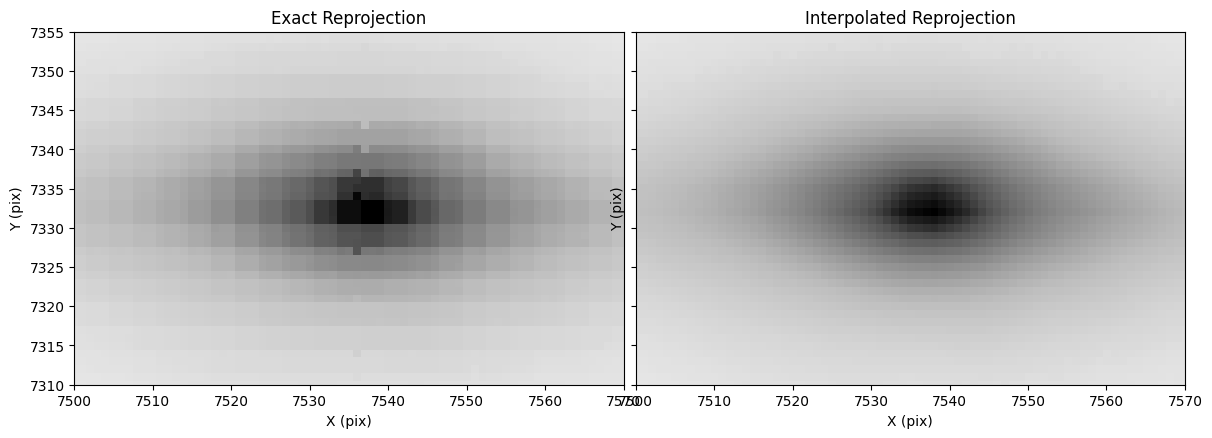

In [28]:
# plot exact and interp images
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
im0 = ax[0].imshow(
    exact_image[0].data,
    origin="lower",
    vmin=np.nanmin(exact_image[0].data),
    vmax=np.nanmax(exact_image[0].data),
    cmap='Greys'
)
ax[0].set_title("Exact Reprojection")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("Y (pix)")
im1 = ax[1].imshow(
    interp_image[0].data,
    origin="lower",
    vmin=np.nanmin(interp_image[0].data),
    vmax=np.nanmax(interp_image[0].data),
    cmap='Greys'
)
ax[1].set_title("Interpolated Reprojection")
ax[1].set_xlabel("X (pix)")
ax[1].set_ylabel("Y (pix)")
plt.tight_layout()
# zoom into the central region
zoom_region_x = (7500, 7570)
zoom_region_y = (7310, 7355)
ax[0].set_xlim(*zoom_region_x)
ax[0].set_ylim(*zoom_region_y)
ax[1].set_xlim(*zoom_region_x)
ax[1].set_ylim(*zoom_region_y)
plt.show()

# Load the image before interpolation

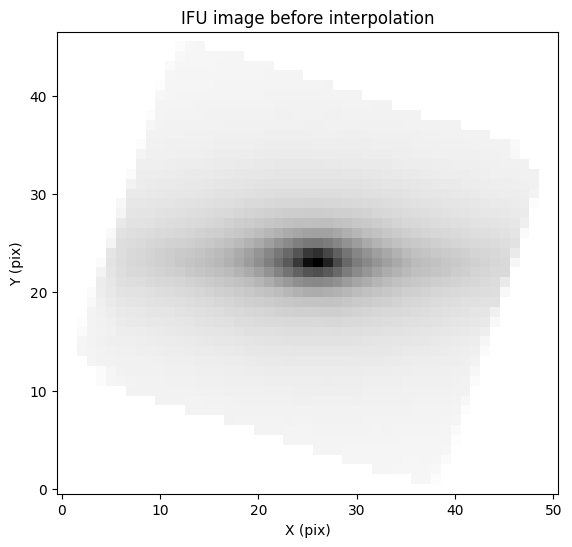

In [55]:
# now the same on the IFU image before interpolation
ifu_f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200_from_ifu_3.fits')
# plot the IFU image
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    ifu_f200[1].data,
    origin="lower",
    vmin=np.nanmin(ifu_f200[1].data),
    vmax=np.nanmax(ifu_f200[1].data),
    cmap = 'Greys'
)
ax.set_title("IFU image before interpolation")
ax.set_xlabel("X (pix)")
ax.set_ylabel("Y (pix)")
plt.show()

In [58]:
# find the maximum pixel in the ifu image for the photometry
max_y, max_x = np.unravel_index(np.nanargmax(ifu_f200[1].data), ifu_f200[1].data.shape)
print(f"Maximum pixel in IFU image: (X={max_x}, Y={max_y})")

Maximum pixel in IFU image: (X=26, Y=23)


# Compute photometry in the central 10 pixels on all 3 and compare

In [65]:
# convert the XY coordinates of the center to celestial coordinates using the WCS of the IFU image
from astropy.wcs import WCS
wcs = WCS(ifu_f200[1].header)
ra, dec = wcs.wcs_pix2world(max_x, max_y, 0)
print(f"Maximum pixel in IFU image corresponds to RA={ra}, Dec={dec}")

Maximum pixel in IFU image corresponds to RA=-170.00239509730588, Dec=-11.623046189498615


Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [91]:
# compare the flux in the central region using a aperture of radius 10 pixels
from photutils.aperture import aperture_photometry
from photutils.aperture import SkyCircularAperture
from astropy.coordinates import SkyCoord    
import astropy.units as u

positions = SkyCoord(ra, dec, unit='deg')
aperture = SkyCircularAperture(positions, r=0.6 * u.arcsec)
# get the wcs of the exact and interp images to convert the positions to pixel coordinates
wcs_exact = WCS(exact_image[0].header)
wcs_interp = WCS(interp_image[0].header)
phot_exact = aperture_photometry(exact_image[0].data, aperture, wcs=wcs_exact)
phot_interp = aperture_photometry(interp_image[0].data, aperture, wcs=wcs_interp)

# now for the original IFU image
wcs_orig = WCS(ifu_f200[1].header)
phot_orig = aperture_photometry(ifu_f200[1].data, aperture, wcs=wcs_orig)

Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [92]:
print(f"Exact flux in aperture: {phot_exact['aperture_sum'][0]}")
print(f"Interpolated flux in aperture: {phot_interp['aperture_sum'][0]}")
print(f"Original IFU flux in aperture: {phot_orig['aperture_sum'][0]}")

Exact flux in aperture: 1973381.3579594602
Interpolated flux in aperture: 1970858.991450509
Original IFU flux in aperture: 192315.34159777162


In [85]:
# print the percentage difference between the exact and interpolated fluxes with respect to the original IFU flux 
exact_diff =  (phot_exact['aperture_sum'][0] - 10*phot_orig['aperture_sum'][0]) / (10*phot_orig['aperture_sum'][0])
interp_diff = (phot_interp['aperture_sum'][0] - 10*phot_orig['aperture_sum'][0]) / (10*phot_orig['aperture_sum'][0])

print(f"Percentage difference between exact and original IFU flux: {exact_diff:.2f}%")
print(f"Percentage difference between interpolated and original IFU flux: {interp_diff:.2f}%")

Percentage difference between exact and original IFU flux: 0.03%
Percentage difference between interpolated and original IFU flux: 0.02%


Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


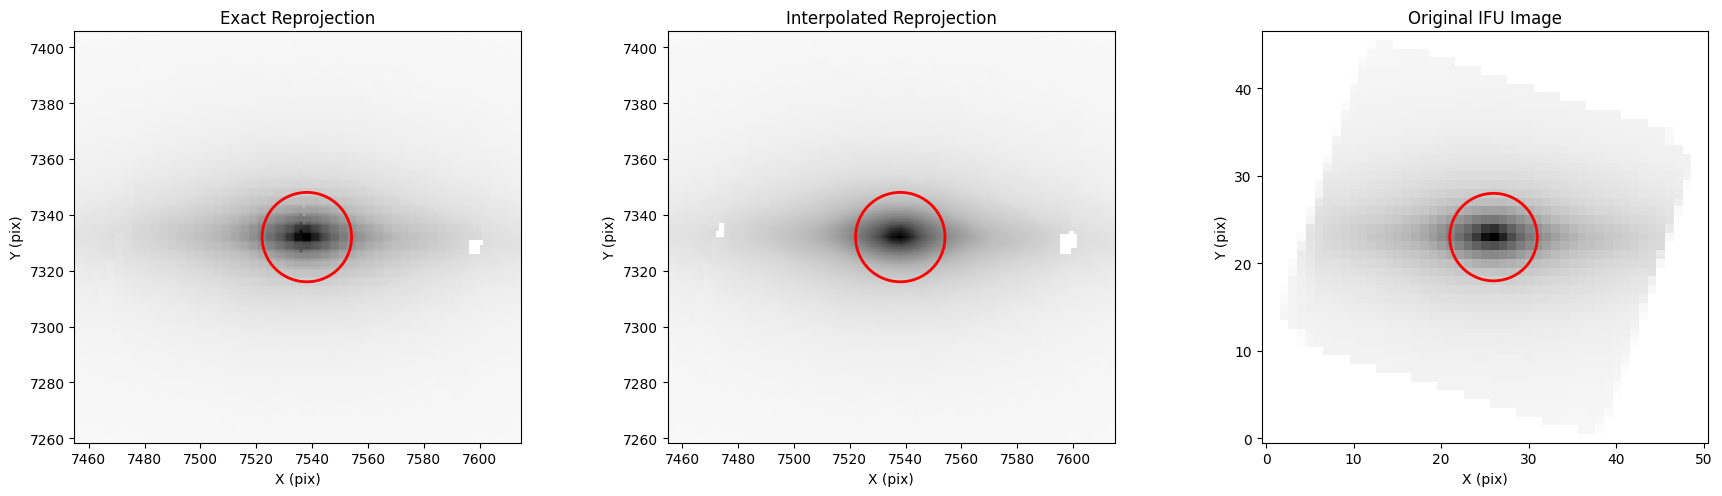

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

# WCS objects
wcs_exact = WCS(exact_image[0].header)
wcs_interp = WCS(interp_image[0].header)
wcs_orig = WCS(ifu_f200[1].header)

# ------------------------------------------------------------
# Use the IFU image footprint as the reference sky region
# ------------------------------------------------------------
ny_ref, nx_ref = ifu_f200[1].data.shape

def get_reference_footprint_skycoords(wcs_ref, nx, ny, nedge=100):
    """Sample the boundary of the reference image in pixel space,
    then convert to sky coordinates."""
    x_bottom = np.linspace(0, nx - 1, nedge)
    y_bottom = np.zeros(nedge)

    x_top = np.linspace(0, nx - 1, nedge)
    y_top = np.full(nedge, ny - 1)

    y_left = np.linspace(0, ny - 1, nedge)
    x_left = np.zeros(nedge)

    y_right = np.linspace(0, ny - 1, nedge)
    x_right = np.full(nedge, nx - 1)

    x = np.concatenate([x_bottom, x_top, x_left, x_right])
    y = np.concatenate([y_bottom, y_top, y_left, y_right])

    return wcs_ref.pixel_to_world(x, y)

ref_sky = get_reference_footprint_skycoords(wcs_orig, nx_ref, ny_ref)

def sky_limits_in_target_pixels(target_wcs, skycoords, shape):
    """Convert a sky footprint to pixel limits in a target WCS."""
    x, y = target_wcs.world_to_pixel(ref_sky)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    ny, nx = shape

    xlo = max(-0.5, np.nanmin(x))
    xhi = min(nx - 0.5, np.nanmax(x))
    ylo = max(-0.5, np.nanmin(y))
    yhi = min(ny - 0.5, np.nanmax(y))

    return xlo, xhi, ylo, yhi

lims_exact  = sky_limits_in_target_pixels(wcs_exact,  ref_sky, exact_image[0].data.shape)
lims_interp = sky_limits_in_target_pixels(wcs_interp, ref_sky, interp_image[0].data.shape)
lims_orig   = (-0.5, nx_ref - 0.5, -0.5, ny_ref - 0.5)  # full IFU image by definition

# ------------------------------------------------------------
# Convert the sky aperture to pixel apertures for plotting
# ------------------------------------------------------------
ap_exact = aperture.to_pixel(wcs_exact)
ap_interp = aperture.to_pixel(wcs_interp)
ap_orig = aperture.to_pixel(wcs_orig)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 5))  # do NOT use sharex/sharey here

im0 = ax[0].imshow(
    exact_image[0].data,
    origin="lower",
    vmin=np.nanmin(exact_image[0].data),
    vmax=np.nanmax(exact_image[0].data),
    cmap="Greys"
)
ap_exact.plot(ax=ax[0], color="red", lw=2)
ax[0].set_xlim(lims_exact[0], lims_exact[1])
ax[0].set_ylim(lims_exact[2], lims_exact[3])
ax[0].set_title("Exact Reprojection")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("Y (pix)")

im1 = ax[1].imshow(
    interp_image[0].data,
    origin="lower",
    vmin=np.nanmin(interp_image[0].data),
    vmax=np.nanmax(interp_image[0].data),
    cmap="Greys"
)
ap_interp.plot(ax=ax[1], color="red", lw=2)
ax[1].set_xlim(lims_interp[0], lims_interp[1])
ax[1].set_ylim(lims_interp[2], lims_interp[3])
ax[1].set_title("Interpolated Reprojection")
ax[1].set_xlabel("X (pix)")
ax[1].set_ylabel("Y (pix)")

im2 = ax[2].imshow(
    ifu_f200[1].data,
    origin="lower",
    vmin=np.nanmin(ifu_f200[1].data),
    vmax=np.nanmax(ifu_f200[1].data),
    cmap="Greys"
)
ap_orig.plot(ax=ax[2], color="red", lw=2)
ax[2].set_xlim(lims_orig[0], lims_orig[1])
ax[2].set_ylim(lims_orig[2], lims_orig[3])
ax[2].set_title("Original IFU Image")
ax[2].set_xlabel("X (pix)")
ax[2].set_ylabel("Y (pix)")

plt.tight_layout()
plt.show()

# Convert to flux per pixel for photometry matching

In [93]:
from astropy.wcs.utils import proj_plane_pixel_area
import astropy.units as u

for name, wcs, hdu in [
    ("exact",  wcs_exact.celestial,  exact_image[0]),
    ("interp", wcs_interp.celestial, interp_image[0]),
    ("orig",   wcs_orig.celestial,   ifu_f200[1]),
]:
    pixarea = (proj_plane_pixel_area(wcs) * u.deg**2).to(u.arcsec**2)
    print(name)
    print("  BUNIT   =", hdu.header.get("BUNIT"))
    print("  pixarea =", pixarea)

exact
  BUNIT   = None
  pixarea = 0.0009750381060443519 arcsec2
interp
  BUNIT   = None
  pixarea = 0.0009750381060443519 arcsec2
orig
  BUNIT   = MJy/sr
  pixarea = 0.010000000298023287 arcsec2


In [97]:
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_area
from photutils.aperture import aperture_photometry, SkyCircularAperture
from astropy.coordinates import SkyCoord
import astropy.units as u

positions = SkyCoord(ra, dec, unit='deg')
aperture = SkyCircularAperture(positions, r=1 * u.arcsec)

wcs_exact  = WCS(exact_image[0].header).celestial
wcs_interp = WCS(interp_image[0].header).celestial
wcs_orig   = WCS(ifu_f200[1].header).celestial

def mjysr_to_mjypix(data, wcs):
    pixarea_sr = (proj_plane_pixel_area(wcs) * u.deg**2).to(u.sr).value
    return data * pixarea_sr

data_exact_flux  = mjysr_to_mjypix(exact_image[0].data,  wcs_exact)
data_interp_flux = mjysr_to_mjypix(interp_image[0].data, wcs_interp)
data_orig_flux   = mjysr_to_mjypix(ifu_f200[1].data,     wcs_orig)

phot_exact  = aperture_photometry(data_exact_flux,  aperture, wcs=wcs_exact)
phot_interp = aperture_photometry(data_interp_flux, aperture, wcs=wcs_interp)
phot_orig   = aperture_photometry(data_orig_flux,   aperture, wcs=wcs_orig)

print("exact  [MJy] =", phot_exact["aperture_sum"][0])
print("interp [MJy] =", phot_interp["aperture_sum"][0])
print("orig   [MJy] =", phot_orig["aperture_sum"][0])

Set OBSGEO-B to   -38.040306 from OBSGEO-[XYZ].
Set OBSGEO-H to 1744349933.102 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


exact  [MJy] = 9.046863832247526e-08
interp [MJy] = 9.037331064376717e-08
orig   [MJy] = 9.080078815890549e-08


In [98]:
# print the percentage difference between the exact and interpolated fluxes
percent_diff = 100 * (phot_exact['aperture_sum'][0] - phot_orig['aperture_sum'][0]) / phot_orig['aperture_sum'][0]
print(f"Percentage difference between exact and original IFU flux: {percent_diff:.2f}%")

percent_diff = 100 * (phot_interp['aperture_sum'][0] - phot_orig['aperture_sum'][0]) / phot_orig['aperture_sum'][0]
print(f"Percentage difference between interpolated and original IFU flux: {percent_diff:.2f}%")

Percentage difference between exact and original IFU flux: -0.37%
Percentage difference between interpolated and original IFU flux: -0.47%


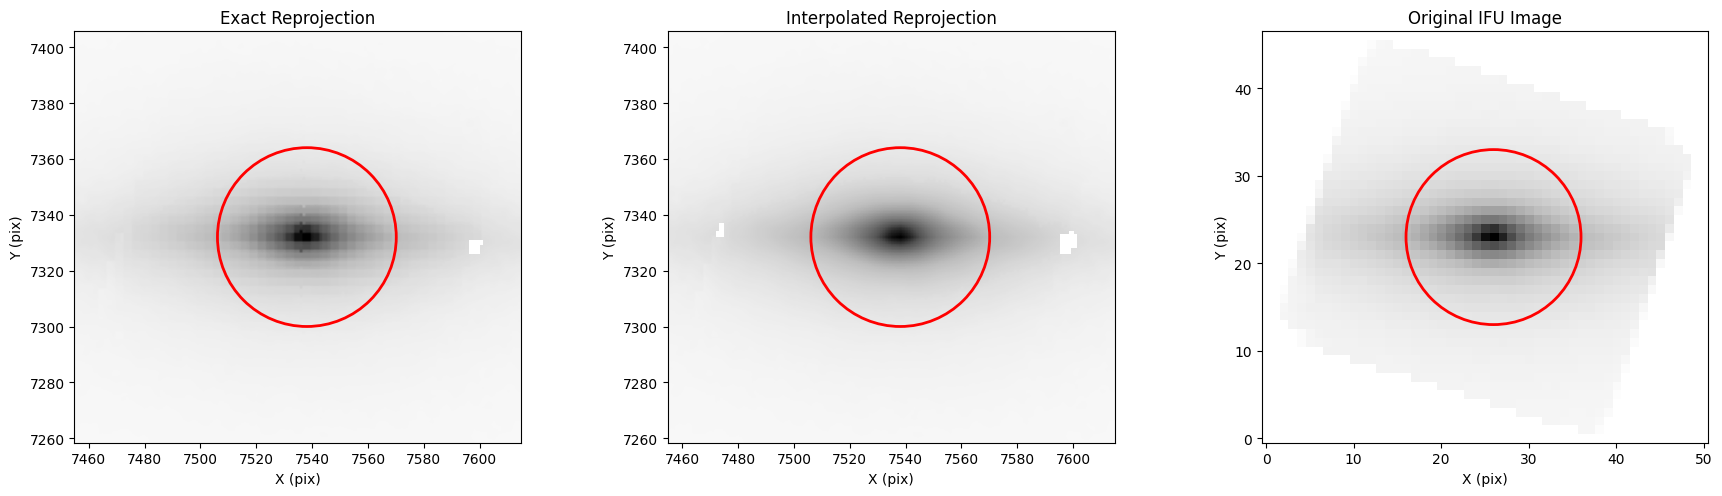

In [99]:

# ------------------------------------------------------------
# Convert the sky aperture to pixel apertures for plotting
# ------------------------------------------------------------
ap_exact = aperture.to_pixel(wcs_exact)
ap_interp = aperture.to_pixel(wcs_interp)
ap_orig = aperture.to_pixel(wcs_orig)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 5))  # do NOT use sharex/sharey here

im0 = ax[0].imshow(
    exact_image[0].data,
    origin="lower",
    vmin=np.nanmin(exact_image[0].data),
    vmax=np.nanmax(exact_image[0].data),
    cmap="Greys"
)
ap_exact.plot(ax=ax[0], color="red", lw=2)
ax[0].set_xlim(lims_exact[0], lims_exact[1])
ax[0].set_ylim(lims_exact[2], lims_exact[3])
ax[0].set_title("Exact Reprojection")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("Y (pix)")

im1 = ax[1].imshow(
    interp_image[0].data,
    origin="lower",
    vmin=np.nanmin(interp_image[0].data),
    vmax=np.nanmax(interp_image[0].data),
    cmap="Greys"
)
ap_interp.plot(ax=ax[1], color="red", lw=2)
ax[1].set_xlim(lims_interp[0], lims_interp[1])
ax[1].set_ylim(lims_interp[2], lims_interp[3])
ax[1].set_title("Interpolated Reprojection")
ax[1].set_xlabel("X (pix)")
ax[1].set_ylabel("Y (pix)")

im2 = ax[2].imshow(
    ifu_f200[1].data,
    origin="lower",
    vmin=np.nanmin(ifu_f200[1].data),
    vmax=np.nanmax(ifu_f200[1].data),
    cmap="Greys"
)
ap_orig.plot(ax=ax[2], color="red", lw=2)
ax[2].set_xlim(lims_orig[0], lims_orig[1])
ax[2].set_ylim(lims_orig[2], lims_orig[3])
ax[2].set_title("Original IFU Image")
ax[2].set_xlabel("X (pix)")
ax[2].set_ylabel("Y (pix)")

plt.tight_layout()
plt.show()